# HPC Efficiency Analysis — King's Sustainability Month

**Data period:** July – December 2025 (6 months)

This notebook generates plots for the sustainability blog post. All efficiency
values are **filtered to ≤ 100 %** for clarity. Plots are saved to
`../results/plots/2026-02_sustainability/`.

## Contents
1. [Global Efficiency Stats](#1.-Global-Efficiency-Stats)
2. [Faculty Efficiency Stats](#2.-Faculty-Efficiency-Stats)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import seaborn as sns
import textwrap, os
from scipy import stats as sp_stats
from scipy.stats import gaussian_kde
from IPython.display import display, Markdown

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'font.size': 11,
})

PLOT_DIR = '../results/plots/2026-02_sustainability'
os.makedirs(PLOT_DIR, exist_ok=True)

# Colours
C_CPU  = '#2196F3'
C_MEM  = '#4CAF50'
C_OK   = '#4CAF50'
C_FAIL = '#F44336'
C_CAN  = '#9E9E9E'
DATE_RANGE = 'July – December 2025'

def savefig(name):
    plt.savefig(os.path.join(PLOT_DIR, name))
    print(f'  Saved {name}')

def fmt_count(x, _):
    """Format job counts: k for thousands, M for millions."""
    if abs(x) >= 1_000_000:
        return f'{x / 1_000_000:.1f}M'
    elif abs(x) >= 1_000:
        return f'{x / 1_000:.0f}k'
    else:
        return f'{x:.0f}'

COUNT_FMT = mticker.FuncFormatter(fmt_count)

In [2]:
JOB_CSV = '../results/2025-07-01_2025-12-31_job_level_metrics.csv'
AGG_CSV = '../results/2025-07-01_2025-12-31_hpc_stats_output.csv'

# --- Job-level data (COMPLETED + TIMEOUT + OOM only) ---
df = pd.read_csv(JOB_CSV, comment='#')
df['faculty'] = df['faculty'].str.strip('"')
df = df.replace('NULL', np.nan)

num_cols = [c for c in df.columns
            if c not in ('username', 'faculty', 'submission_type')]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

FACULTY_MERGE = {
    'Faculty of Life Sciences and Medicine':
        'Faculty of Life Sciences & Medicine',
    'IoPPN':
        'Institute of Psychiatry, Psychology & Neuroscience',
    'Dentistry, Oral & Craniofacial Sciences':
        'Faculty of Dentistry, Oral & Craniofacial Sciences',
    'Social Science & Public Policy':
        'Faculty of Social Science & Public Policy',
}
df['faculty'] = df['faculty'].replace(FACULTY_MERGE)

def shorten(name):
    s = name.replace('Faculty of ', '').replace('Institute of ', '')
    return '\n'.join(textwrap.wrap(s, width=20))

df['faculty_short'] = df['faculty'].apply(shorten)
SHORT = dict(zip(df['faculty'], df['faculty_short']))

# --- Aggregate data (all job states, for total counts) ---
df_agg = pd.read_csv(AGG_CSV, comment='#')
df_agg['faculty'] = df_agg['faculty'].str.strip('"')
df_agg['faculty'] = df_agg['faculty'].replace(FACULTY_MERGE)

# Drop the "all" row (global stats appended by --collate_by none)
df_agg = df_agg[df_agg['faculty'] != 'all']

agg_cols = ['job_count', 'job_count_success', 'job_count_failed',
            'count_timeout', 'count_out_of_memory']
df_agg = df_agg.groupby('faculty')[agg_cols].sum().reset_index()
df_agg['cancelled'] = (df_agg['job_count']
                        - df_agg['job_count_success']
                        - df_agg['job_count_failed'])
df_agg['faculty_short'] = df_agg['faculty'].map(SHORT).fillna(
    df_agg['faculty'].apply(shorten))

total_all = df_agg['job_count'].sum()
total_eff = len(df)
total_excluded = total_all - total_eff
print(f'Efficiency jobs: {total_eff:,}  (COMPLETED + TIMEOUT + OOM)')
print(f'Total jobs incl. all states: {total_all:,}')
print(f'Excluded: {total_excluded:,} (CANCELLED + FAILED + NODE_FAIL + PREEMPTED)')
print(f'Date range: {DATE_RANGE}')

Efficiency jobs: 2,916,254  (COMPLETED + TIMEOUT + OOM)
Total jobs incl. all states: 3,717,485
Excluded: 801,231 (CANCELLED + FAILED + NODE_FAIL + PREEMPTED)
Date range: July – December 2025


---
# 1. Global Efficiency Stats

In [3]:
cpu_valid = df['cpu_eff_req'].dropna()
mem_valid = df['mem_eff'].dropna()

cpu_le100 = cpu_valid[cpu_valid <= 100]
mem_le100 = mem_valid[mem_valid <= 100]

display(Markdown(f'''
## Cluster-Wide Summary (Average Efficiency)

| Metric | Value |
|--------|-------|
| **Total jobs submitted** | {total_all:,} |
| **Jobs analysed for efficiency** | {total_eff:,} |
| **Mean CPU efficiency** | {cpu_le100.mean():.1f} % |
| **Median CPU efficiency** | {cpu_le100.median():.1f} % |
| **Mean memory efficiency** | {mem_le100.mean():.1f} % |
| **Median memory efficiency** | {mem_le100.median():.1f} % |
| **Jobs with CPU eff > 100 %** | {(cpu_valid > 100).sum():,} ({(cpu_valid > 100).mean()*100:.1f} %, excluded) |
| **Jobs with mem eff > 100 %** | {(mem_valid > 100).sum():,} ({(mem_valid > 100).mean()*100:.1f} %, excluded) |

**Included states:** COMPLETED, TIMEOUT, OUT_OF_MEMORY — jobs that ran long
enough to produce meaningful resource usage data.

**Excluded:** {total_excluded:,} jobs in states CANCELLED, FAILED, NODE_FAIL,
and PREEMPTED were excluded from all efficiency analysis because they did not
run to completion and their resource usage is not representative.

Efficiency values above 100 % are excluded from the averages and all plots
below. These arise from Slurm’s core-level allocation (CPU) or historically
unenforced memory limits.
'''))



## Cluster-Wide Summary (Average Efficiency)

| Metric | Value |
|--------|-------|
| **Total jobs submitted** | 3,717,485 |
| **Jobs analysed for efficiency** | 2,916,254 |
| **Mean CPU efficiency** | 59.9 % |
| **Median CPU efficiency** | 70.6 % |
| **Mean memory efficiency** | 19.3 % |
| **Median memory efficiency** | 8.5 % |
| **Jobs with CPU eff > 100 %** | 97,342 (3.4 %, excluded) |
| **Jobs with mem eff > 100 %** | 274,154 (9.4 %, excluded) |

**Included states:** COMPLETED, TIMEOUT, OUT_OF_MEMORY — jobs that ran long
enough to produce meaningful resource usage data.

**Excluded:** 801,231 jobs in states CANCELLED, FAILED, NODE_FAIL,
and PREEMPTED were excluded from all efficiency analysis because they did not
run to completion and their resource usage is not representative.

Efficiency values above 100 % are excluded from the averages and all plots
below. These arise from Slurm’s core-level allocation (CPU) or historically
unenforced memory limits.


  Saved job_state_distribution.png


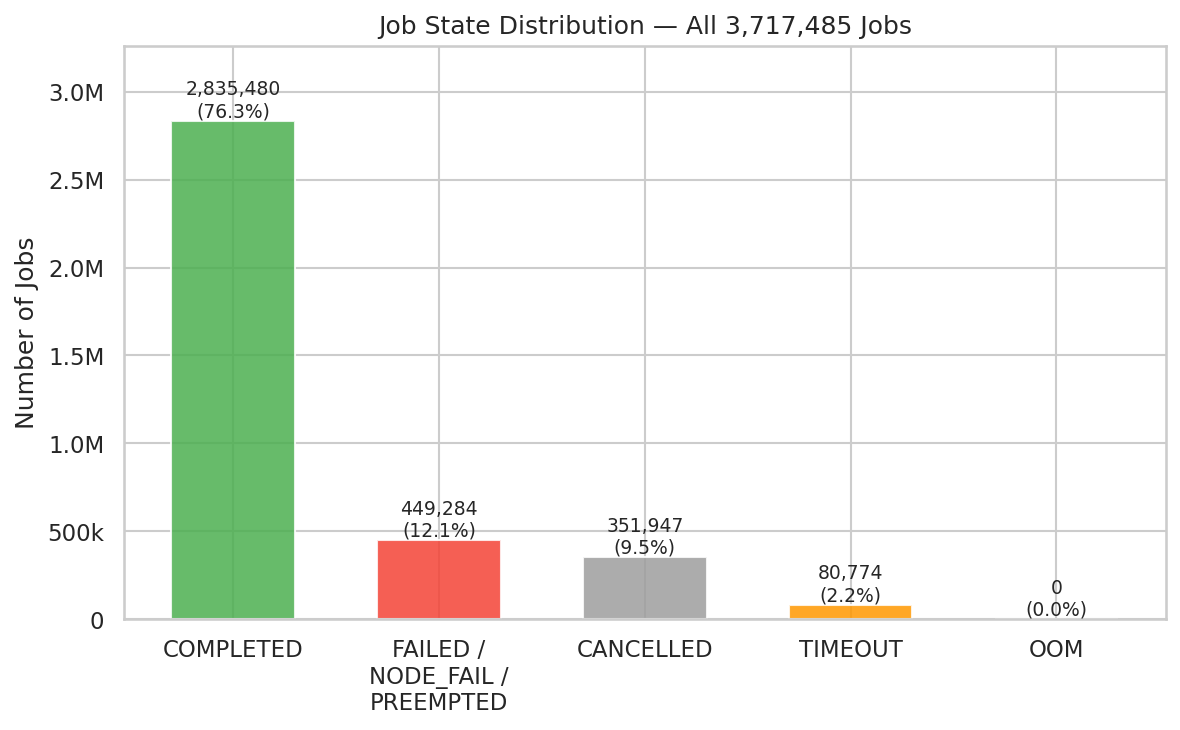


**Included in efficiency analysis:** COMPLETED + TIMEOUT + OOM
= **2,916,254** jobs.

**Excluded:** CANCELLED + FAILED + NODE_FAIL + PREEMPTED
= **801,231** jobs — these either did not run long enough or
terminated abnormally, so their resource usage is not representative.


In [4]:
# State breakdown from aggregate data
agg_completed = df_agg['job_count_success'].sum()
agg_timeout = df_agg['count_timeout'].sum()
agg_oom = df_agg['count_out_of_memory'].sum()
agg_failed_total = df_agg['job_count_failed'].sum()
agg_other_failed = agg_failed_total - agg_timeout - agg_oom
agg_cancelled = df_agg['cancelled'].sum()

state_labels = ['COMPLETED', 'FAILED /\nNODE_FAIL /\nPREEMPTED', 'CANCELLED', 'TIMEOUT', 'OOM']
state_counts = [agg_completed, agg_other_failed, agg_cancelled, agg_timeout, agg_oom]
state_colors = [C_OK, C_FAIL, C_CAN, '#FF9800', '#9C27B0']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(state_labels, state_counts, color=state_colors, edgecolor='white',
              width=0.6, alpha=0.85)

for bar, count in zip(bars, state_counts):
    pct = count / total_all * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Number of Jobs')
# Auto-scale y-axis with room for annotations
y_max = max(state_counts)
ax.set_ylim(0, y_max * 1.15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else
                 f'{x/1e3:.0f}k' if x >= 1e3 else f'{x:.0f}'))
ax.set_title(f'Job State Distribution — All {total_all:,} Jobs')
plt.tight_layout()
savefig('job_state_distribution.png')
plt.show()

display(Markdown(f'''
**Included in efficiency analysis:** COMPLETED + TIMEOUT + OOM
= **{total_eff:,}** jobs.

**Excluded:** CANCELLED + FAILED + NODE_FAIL + PREEMPTED
= **{total_excluded:,}** jobs — these either did not run long enough or
terminated abnormally, so their resource usage is not representative.
'''))

<>:31: SyntaxWarning: invalid escape sequence '\>'
<>:31: SyntaxWarning: invalid escape sequence '\>'
/tmp/ipykernel_353087/564965814.py:31: SyntaxWarning: invalid escape sequence '\>'


  Saved cpu_efficiency_density.png


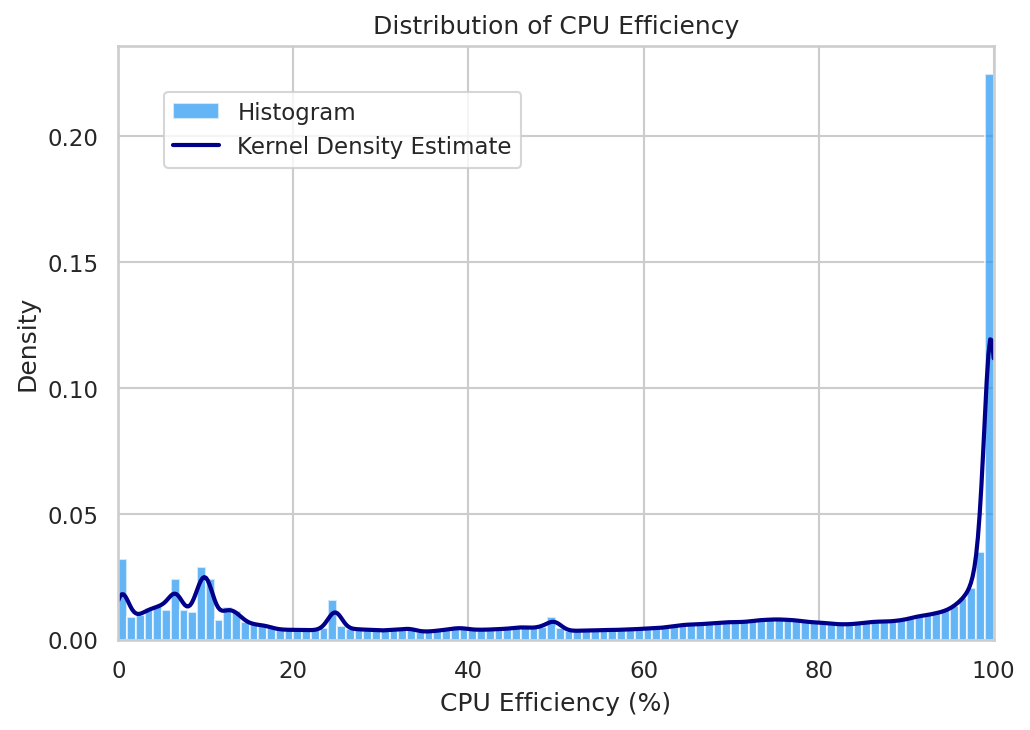


*Based on **2,807,463** jobs. From 2,916,254 efficiency jobs,
11,449 with null CPU efficiency and 97,342 with CPU efficiency
\> 100% were excluded.*


In [5]:
cpu_data = df['cpu_eff_req'].dropna()
cpu_plot = cpu_data[cpu_data <= 100]
cpu_null = total_eff - len(cpu_data)
cpu_over = len(cpu_data) - len(cpu_plot)

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(cpu_plot, bins=100, color=C_CPU, alpha=0.7, edgecolor='white',
        density=True, label='Histogram')

# KDE overlay (subsample for speed)
sample = cpu_plot.sample(min(500_000, len(cpu_plot)), random_state=42)
kde = gaussian_kde(sample, bw_method=0.02)
x_grid = np.linspace(0, 100, 500)
ax.plot(x_grid, kde(x_grid), color='darkblue', lw=2, label='Kernel Density Estimate')

ax.set_xlabel('CPU Efficiency (%)')
ax.set_ylabel('Density')
ax.set_title('Distribution of CPU Efficiency')
ax.set_xlim(0, 100)
ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
ax.legend(loc='upper left', borderaxespad=2)
plt.tight_layout()
savefig('cpu_efficiency_density.png')
plt.show()

display(Markdown(f'''
*Based on **{len(cpu_plot):,}** jobs. From {total_eff:,} efficiency jobs,
{cpu_null:,} with null CPU efficiency and {cpu_over:,} with CPU efficiency
\> 100% were excluded.*
'''))

In [ ]:

# Split by single-CPU vs multi-CPU jobs
single_cpu = df[df['req_cpus'] == 1]
multi_cpu_all = df[df['req_cpus'] > 1]

single_cpu_eff = single_cpu['cpu_eff_req'].dropna()
single_cpu_plot = single_cpu_eff[single_cpu_eff <= 100]

multi_cpu_eff = multi_cpu_all['cpu_eff_req'].dropna()
multi_cpu_plot = multi_cpu_eff[multi_cpu_eff <= 100]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, color, dark, title, leg_loc in [
    (axes[0], single_cpu_plot, C_CPU, 'darkblue',
     'Single-CPU Requests', 'upper left'),
    (axes[1], multi_cpu_plot, '#FF9800', '#CC6600',
     'Multi-CPU Requests', 'upper right'),
]:
    ax.hist(data, bins=100, color=color, alpha=0.7, edgecolor='white',
            density=True, label='Histogram')
    sample = data.sample(min(500_000, len(data)), random_state=42)
    kde = gaussian_kde(sample, bw_method=0.02)
    x_grid = np.linspace(0, 100, 500)
    ax.plot(x_grid, kde(x_grid), color=dark, lw=2, label='Kernel Density Estimate')
    ax.set_xlabel('CPU Efficiency (%)')
    ax.set_ylabel('Density')
    ax.set_title(f'{title}\n(n = {len(data):,})')
    ax.set_xlim(0, 100)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
    ax.legend(loc=leg_loc)

plt.suptitle('CPU Efficiency: Single-CPU vs Multi-CPU Jobs',
             fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('cpu_efficiency_density_split.png')
plt.show()

display(Markdown(f'''
*Left: {len(single_cpu_plot):,} single-CPU jobs (efficiency ≤ 100 %,
{len(single_cpu_eff) - len(single_cpu_plot):,} excluded).
Right: {len(multi_cpu_plot):,} multi-CPU jobs (efficiency ≤ 100 %,
{len(multi_cpu_eff) - len(multi_cpu_plot):,} excluded).*
'''))

In [ ]:
mem_data = df['mem_eff'].dropna()
mem_plot = mem_data[mem_data <= 100]
mem_null = total_eff - len(mem_data)
mem_over = len(mem_data) - len(mem_plot)

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(mem_plot, bins=100, color=C_MEM, alpha=0.7, edgecolor='white',
        density=True, label='Histogram')

sample = mem_plot.sample(min(500_000, len(mem_plot)), random_state=42)
kde = gaussian_kde(sample, bw_method=0.02)
x_grid = np.linspace(0, 100, 500)
ax.plot(x_grid, kde(x_grid), color='darkgreen', lw=2, label='Kernel Density Estimate')

ax.set_xlabel('Memory Efficiency (%)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Memory Efficiency')
ax.set_xlim(0, 100)
ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
ax.legend(loc='upper right', borderaxespad=2)
plt.tight_layout()
savefig('mem_efficiency_density.png')
plt.show()

display(Markdown(f'''
*Based on **{len(mem_plot):,}** jobs. From {total_eff:,} efficiency jobs,
{mem_null:,} with null memory efficiency and {mem_over:,} with memory
efficiency \> 100% were excluded.*
'''))

# --- Split by single-GB vs multi-GB memory requests ---
mem_req_gib = df['reqmem_bytes'].dropna() / (1024**3)
df_with_mem = df[df['reqmem_bytes'].notna()].copy()
df_with_mem['reqmem_gib'] = df_with_mem['reqmem_bytes'] / (1024**3)

single_gb = df_with_mem[df_with_mem['reqmem_gib'] <= 1]
multi_gb = df_with_mem[df_with_mem['reqmem_gib'] > 1]

single_gb_eff = single_gb['mem_eff'].dropna()
single_gb_plot = single_gb_eff[single_gb_eff <= 100]

multi_gb_eff = multi_gb['mem_eff'].dropna()
multi_gb_plot = multi_gb_eff[multi_gb_eff <= 100]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, color, dark, title in [
    (axes[0], single_gb_plot, C_MEM, 'darkgreen',
     'Single-GB Requests'),
    (axes[1], multi_gb_plot, '#FF9800', '#CC6600',
     'Multi-GB Requests'),
]:
    n, bin_edges, _ = ax.hist(data, bins=100, color=color, alpha=0.7,
                              edgecolor='white', density=True, label='Histogram')
    if len(data) > 10:
        sample = data.sample(min(500_000, len(data)), random_state=42)
        kde = gaussian_kde(sample, bw_method=0.02)
        x_grid = np.linspace(0, 100, 500)
        kde_vals = kde(x_grid)
        ax.plot(x_grid, kde_vals, color=dark, lw=2, label='Kernel Density Estimate')
        y_top = max(n.max(), kde_vals.max()) * 1.03
    else:
        y_top = n.max() * 1.03
    ax.set_xlabel('Memory Efficiency (%)')
    ax.set_ylabel('Density')
    ax.set_title(f'{title}\n(n = {len(data):,})')
    ax.set_xlim(0, 100)
    ax.set_ylim(0, y_top)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
    ax.legend(loc='upper right')

plt.suptitle('Memory Efficiency: Single-GB vs Multi-GB Requests',
             fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('mem_efficiency_density_split.png')
plt.show()

display(Markdown(f'''
*Left: {len(single_gb_plot):,} jobs requesting ≤ 1 GiB (efficiency ≤ 100 %,
{len(single_gb_eff) - len(single_gb_plot):,} excluded).
Right: {len(multi_gb_plot):,} jobs requesting > 1 GiB (efficiency ≤ 100 %,
{len(multi_gb_eff) - len(multi_gb_plot):,} excluded).*
'''))

In [ ]:
cpus = df['req_cpus'].dropna()

COUNT_FMT_AXIS = mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else
                 f'{x/1e3:.0f}k' if x >= 1e3 else f'{x:.0f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: linear scale, zoomed to the most common range
top = int(cpus.quantile(0.99))
n_left, _, _ = axes[0].hist(cpus[cpus <= top], bins=range(1, top + 2),
                            color=C_CPU, alpha=0.7, edgecolor='white')
axes[0].set_xlabel('CPUs Requested')
axes[0].set_ylabel('Number of Jobs')
axes[0].yaxis.set_major_formatter(COUNT_FMT_AXIS)
axes[0].set_ylim(0, n_left.max() * 1.05)
axes[0].set_title(f'Most common range (1\u2013{top} CPUs)')

# Right: log scale, showing the full range including outliers
n_right_vals, _, _ = axes[1].hist(
    cpus, bins=np.logspace(0, np.log10(cpus.max()), 50),
    color=C_CPU, alpha=0.7, edgecolor='white')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].xaxis.set_major_formatter(mticker.ScalarFormatter())
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.0f}M' if x >= 1e6 else
                 f'{x/1e3:.0f}k' if x >= 1e3 else f'{x:.0f}'))
axes[1].set_xlabel('CPUs Requested')
axes[1].set_ylabel('Number of Jobs (log scale)')
axes[1].set_title('Full range including outliers (log scale)')

plt.suptitle('Distribution of CPUs Requested',
             fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('cpus_requested_distribution.png')
plt.show()

# Summary statistics
display(Markdown(f'''
*Based on all {len(cpus):,} efficiency jobs. Bin size: 1 CPU (left plot). The left plot shows only jobs requesting up to
{top} CPUs (the 99th percentile), so the bulk of the distribution is visible.
The right plot uses logarithmic axes to show the full range.*

| Stat | Value |
|------|-------|
| Median | {cpus.median():.0f} |
| Mean | {cpus.mean():.1f} |
| 95th percentile | {cpus.quantile(0.95):.0f} |
| Max | {cpus.max():.0f} |
| % requesting 1 CPU | {(cpus == 1).mean()*100:.1f} % |
'''))

# Top 10 most frequent CPU request values
top10 = cpus.value_counts().head(10).sort_values(ascending=False)
rows = []
for val, count in top10.items():
    rows.append(f'| {int(val)} | {count:,} | {count / len(cpus) * 100:.1f} % |')
table = '\n'.join(rows)

display(Markdown(f'''
**Top 10 most frequently requested CPU counts:**

| CPUs | Jobs | % |
|------|------|---|
{table}
'''))

In [ ]:
mem_req_gib = df['reqmem_bytes'].dropna() / (1024**3)

COUNT_FMT_AXIS2 = mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else
                 f'{x/1e3:.0f}k' if x >= 1e3 else f'{x:.0f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_mem = mem_req_gib.quantile(0.99)
n_bins_left = 50
bin_width = top_mem / n_bins_left
n_left, _, _ = axes[0].hist(mem_req_gib[mem_req_gib <= top_mem], bins=n_bins_left,
                            color=C_MEM, alpha=0.7, edgecolor='white')
axes[0].set_xlabel('Memory Requested (GiB)')
axes[0].set_ylabel('Number of Jobs')
axes[0].yaxis.set_major_formatter(COUNT_FMT_AXIS2)
axes[0].set_ylim(0, n_left.max() * 1.05)
axes[0].set_title(f'Most common range (up to {top_mem:.0f} GiB)')

# Right: log-log
log_bins = np.logspace(np.log10(max(0.01, mem_req_gib.min())),
                       np.log10(mem_req_gib.max()), 50)
n_right_vals, _, _ = axes[1].hist(mem_req_gib, bins=log_bins,
                                  color=C_MEM, alpha=0.7, edgecolor='white')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].xaxis.set_major_locator(mticker.LogLocator(base=10))
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.0f}M' if x >= 1e6 else
                 f'{x/1e3:.0f}k' if x >= 1e3 else
                 f'{x:.0f}' if x >= 1 else f'{x:.2g}'))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.0f}M' if x >= 1e6 else
                 f'{x/1e3:.0f}k' if x >= 1e3 else f'{x:.0f}'))
axes[1].set_xlabel('Memory Requested (GiB)')
axes[1].set_ylabel('Number of Jobs (log scale)')
axes[1].set_title('Full range including outliers (log scale)')

plt.suptitle('Distribution of Memory Requested',
             fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('memory_requested_distribution.png')
plt.show()

# Summary statistics
display(Markdown(f'''
*Based on all {len(mem_req_gib):,} efficiency jobs. Bin size: {bin_width:.1f} GiB (left plot). The left plot shows only jobs
requesting up to {top_mem:.0f} GiB (the 99th percentile). The right plot uses
logarithmic axes to show the full range.*

| Stat | Value |
|------|-------|
| Median | {mem_req_gib.median():.1f} GiB |
| Mean | {mem_req_gib.mean():.1f} GiB |
| 95th percentile | {mem_req_gib.quantile(0.95):.1f} GiB |
| Max | {mem_req_gib.max():.0f} GiB |
'''))

# Top 10 most frequent memory request values
mem_req_rounded = mem_req_gib.round(1)
top10m = mem_req_rounded.value_counts().head(10).sort_values(ascending=False)
rows = []
for val, count in top10m.items():
    rows.append(f'| {val:.1f} | {count:,} | {count / len(mem_req_gib) * 100:.1f} % |')
table = '\n'.join(rows)

display(Markdown(f'''
**Top 10 most frequently requested memory amounts:**

| GiB | Jobs | % |
|-----|------|---|
{table}
'''))

  Saved wait_time_distribution.png


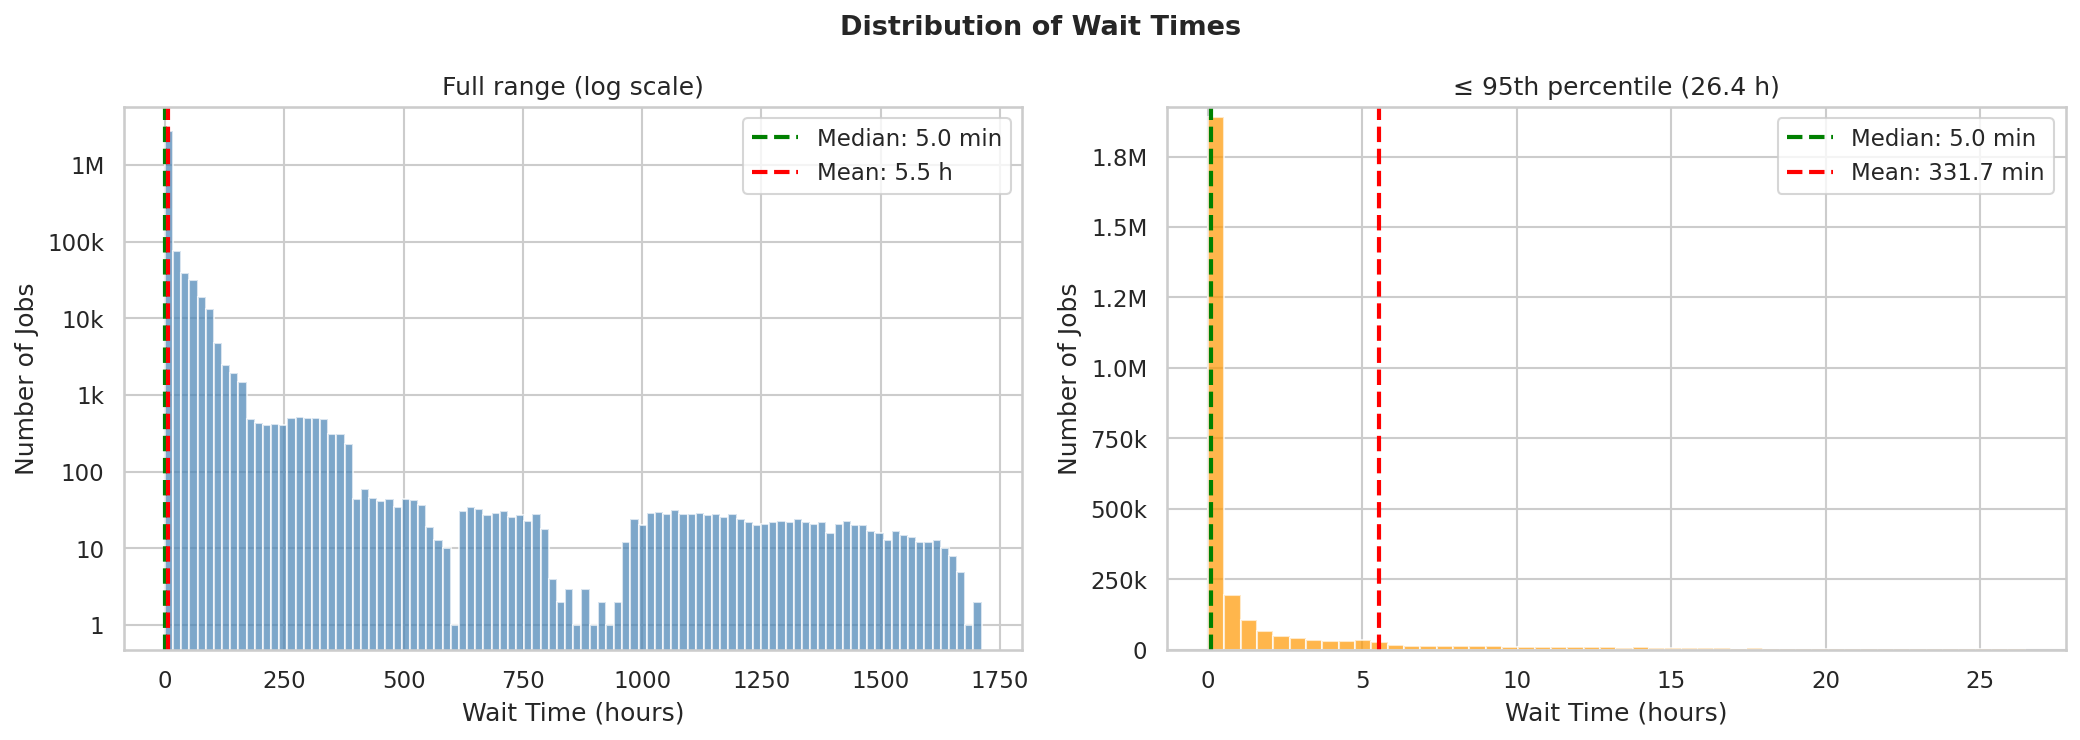


*Based on **2,916,254** jobs.
Most jobs (95 %) wait less than
**26.4 hours**. The median wait is **5.0 minutes**.*

| Stat | Value |
|------|-------|
| Median | 5.0 min (0.08 h) |
| Mean | 331.7 min (5.5 h) |
| 95th percentile | 26.4 h |
| Max | 1711 h |


In [10]:
wait_data = df['wait_sec'].dropna()
wait_hours = wait_data / 3600

median_w = wait_hours.median()
mean_w = wait_hours.mean()
p95_w = wait_hours.quantile(0.95)
median_min = median_w * 60
mean_min = mean_w * 60

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full range, log scale
axes[0].hist(wait_hours, bins=100, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].axvline(median_w, color='green', linestyle='--', linewidth=2,
                label=f'Median: {median_min:.1f} min')
axes[0].axvline(mean_w, color='red', linestyle='--', linewidth=2,
                label=f'Mean: {mean_w:.1f} h')
axes[0].set_xlabel('Wait Time (hours)')
axes[0].set_ylabel('Number of Jobs')
axes[0].set_title('Full range (log scale)')
axes[0].set_yscale('log')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.0f}M' if x >= 1e6 else
                 f'{x/1e3:.0f}k' if x >= 1e3 else f'{x:.0f}'))
axes[0].legend()

# Right: zoomed to 95th percentile — show both median and mean
zoomed = wait_hours[wait_hours <= p95_w]
axes[1].hist(zoomed, bins=50, color='#FF9800', alpha=0.7, edgecolor='white')
axes[1].axvline(median_w, color='green', linestyle='--', linewidth=2,
                label=f'Median: {median_min:.1f} min')
axes[1].axvline(mean_w, color='red', linestyle='--', linewidth=2,
                label=f'Mean: {mean_min:.1f} min')
axes[1].set_xlabel('Wait Time (hours)')
axes[1].set_ylabel('Number of Jobs')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else
                 f'{x/1e3:.0f}k' if x >= 1e3 else f'{x:.0f}'))
axes[1].margins(y=0.02)
axes[1].set_title(f'\u2264 95th percentile ({p95_w:.1f} h)')
axes[1].legend()

plt.suptitle('Distribution of Wait Times',
             fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('wait_time_distribution.png')
plt.show()

display(Markdown(f'''
*Based on **{len(wait_hours):,}** jobs.
Most jobs ({len(zoomed)/len(wait_hours)*100:.0f} %) wait less than
**{p95_w:.1f} hours**. The median wait is **{median_min:.1f} minutes**.*

| Stat | Value |
|------|-------|
| Median | {median_min:.1f} min ({median_w:.2f} h) |
| Mean | {mean_min:.1f} min ({mean_w:.1f} h) |
| 95th percentile | {p95_w:.1f} h |
| Max | {wait_hours.max():.0f} h |
'''))

  Saved nodes_distribution.png


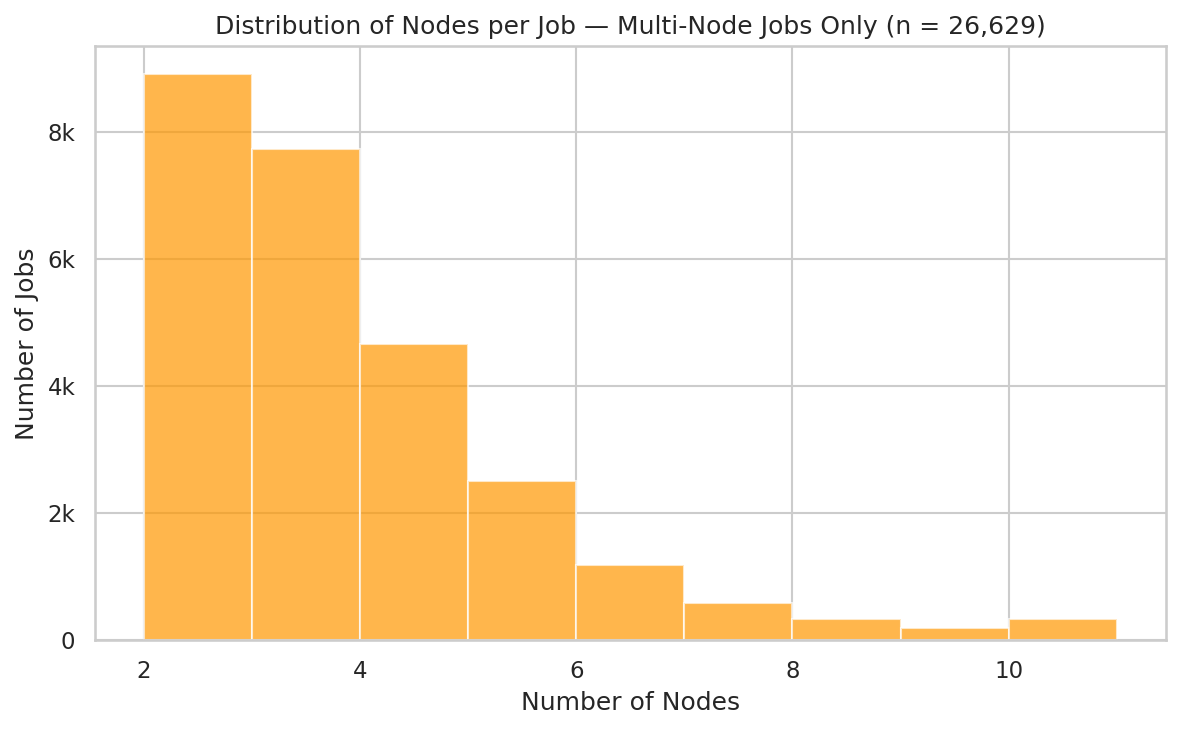


*Based on **2,915,980** jobs.
**2,889,351** (99.1 %) used a single node and
**26,629** (0.9 %) used multiple nodes.
The plot above shows only the multi-node distribution.*

| Stat | Value |
|------|-------|
| Median | 1 |
| Mean | 1.02 |
| Max | 20 |
| % single-node | 99.1 % |


In [11]:
nodes = pd.to_numeric(df['n_nodes'], errors='coerce').dropna()
nodes = nodes[nodes > 0]

n_single = (nodes == 1).sum()
n_multi = (nodes > 1).sum()
pct_single = n_single / len(nodes) * 100

# Only plot multi-node distribution
multi = nodes[nodes > 1]

fig, ax = plt.subplots(figsize=(8, 5))
if len(multi) > 0:
    top_multi = int(multi.quantile(0.99)) if len(multi) > 10 else int(multi.max())
    ax.hist(multi[multi <= top_multi], bins=range(2, top_multi + 2),
            color='#FF9800', alpha=0.7, edgecolor='white')
    ax.set_xlabel('Number of Nodes')
    ax.set_ylabel('Number of Jobs')
    ax.yaxis.set_major_formatter(COUNT_FMT)
    ax.set_title(f'Distribution of Nodes per Job — Multi-Node Jobs Only (n = {n_multi:,})')
else:
    ax.text(0.5, 0.5, 'No multi-node jobs', transform=ax.transAxes,
            ha='center', fontsize=14)

plt.tight_layout()
savefig('nodes_distribution.png')
plt.show()

display(Markdown(f'''
*Based on **{len(nodes):,}** jobs.
**{n_single:,}** ({pct_single:.1f} %) used a single node and
**{n_multi:,}** ({100 - pct_single:.1f} %) used multiple nodes.
The plot above shows only the multi-node distribution.*

| Stat | Value |
|------|-------|
| Median | {nodes.median():.0f} |
| Mean | {nodes.mean():.2f} |
| Max | {nodes.max():.0f} |
| % single-node | {pct_single:.1f} % |
'''))

  Saved severity_barplot.png


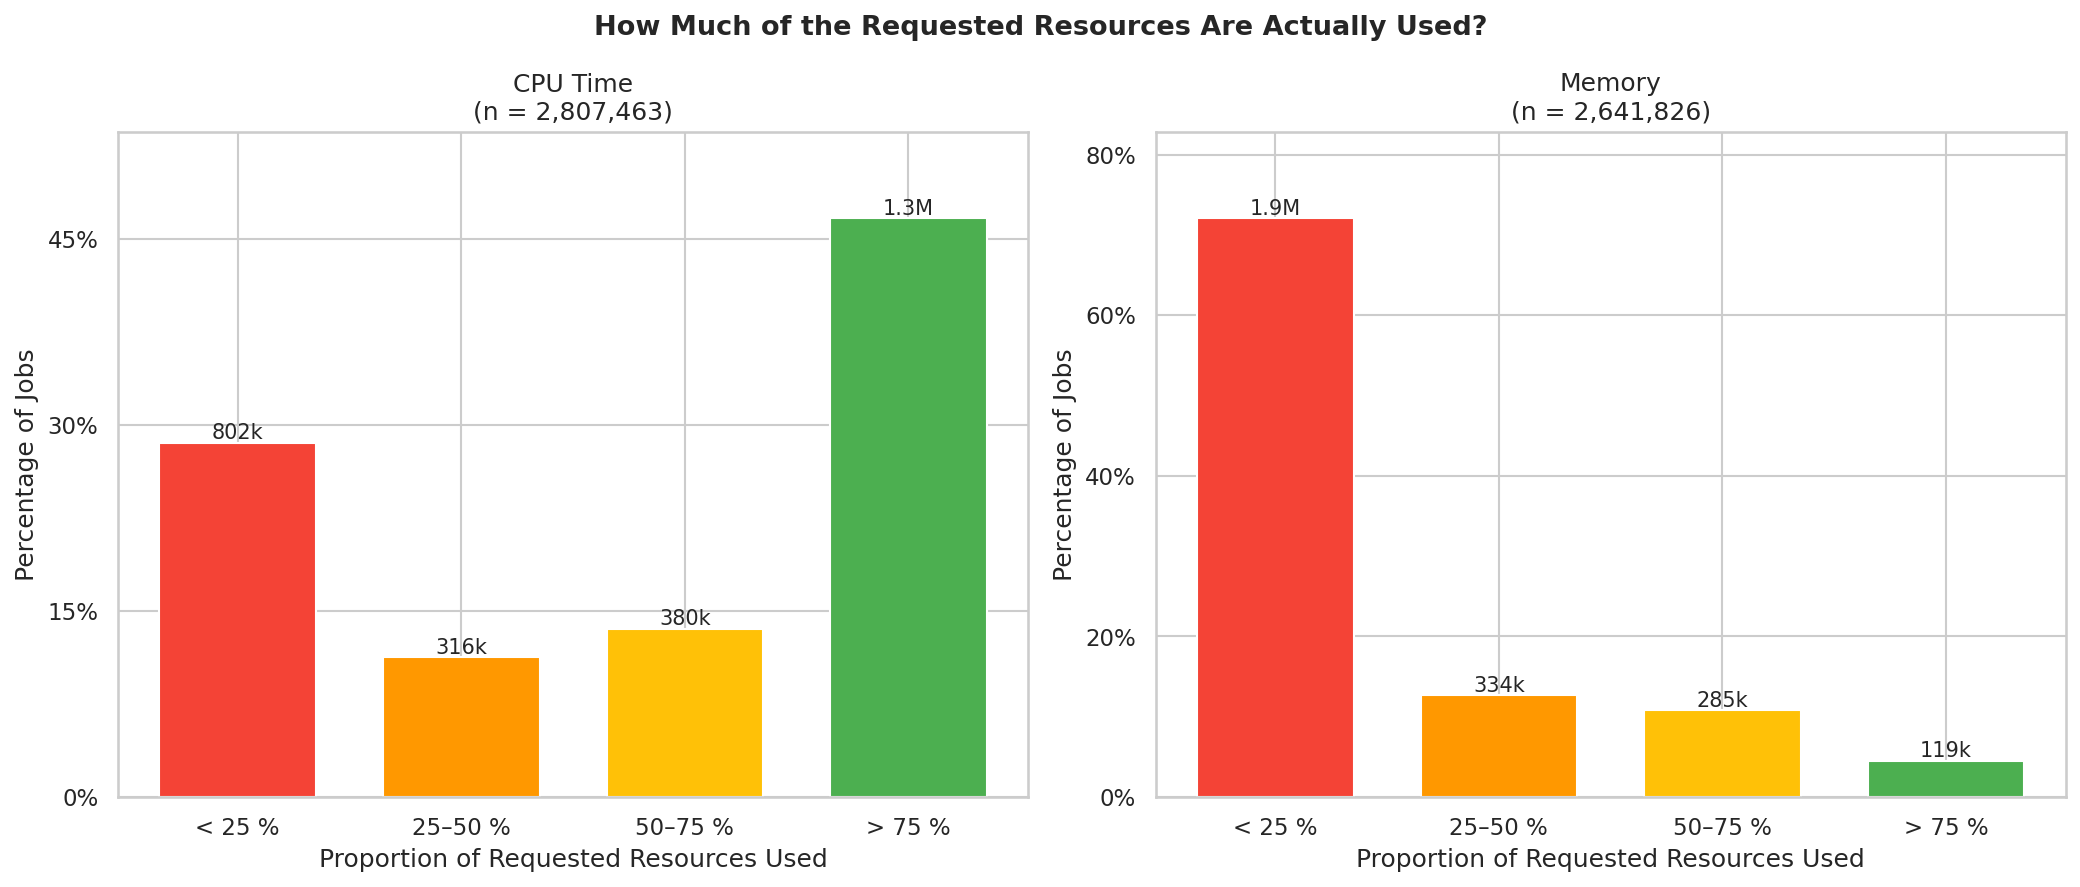


*Each bar shows the percentage of jobs whose efficiency falls into that range.
The number on each bar indicates the absolute job count in that category.*

*Note on sample sizes:* The number of jobs in these plots differs from the
resource distribution plots above. The resource distributions show **all**
2,916,254 efficiency jobs. These severity plots only include jobs with a
**valid** efficiency value **≤ 100 %**. Of the 2,904,805 jobs
with a non-null CPU efficiency, 97,342 had efficiency > 100 % and
are excluded here. Jobs with null efficiency (e.g., zero elapsed time) are
also excluded.

CPU and memory efficiencies are filtered **independently** — a job can appear
in the CPU plot but not the memory plot, or vice versa.


In [12]:
bins   = [0, 25, 50, 75, 100.01]   # 100.01 to include exactly 100
labels = ['< 25 %', '25\u201350 %', '50\u201375 %', '> 75 %']
colors = ['#F44336', '#FF9800', '#FFC107', '#4CAF50']

cpu_filt = df['cpu_eff_req'].dropna()
cpu_filt = cpu_filt[cpu_filt <= 100]
mem_filt = df['mem_eff'].dropna()
mem_filt = mem_filt[mem_filt <= 100]

cpu_bins = pd.cut(cpu_filt, bins=bins, labels=labels, right=False)
mem_bins = pd.cut(mem_filt, bins=bins, labels=labels, right=False)

cpu_counts = cpu_bins.value_counts().reindex(labels, fill_value=0)
mem_counts = mem_bins.value_counts().reindex(labels, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, counts, resource, n in [
    (axes[0], cpu_counts, 'CPU Time', len(cpu_filt)),
    (axes[1], mem_counts, 'Memory', len(mem_filt)),
]:
    pcts = counts.values / n * 100
    bars = ax.bar(labels, pcts, color=colors, edgecolor='white', width=0.7)
    ax.set_xlabel('Proportion of Requested Resources Used')
    ax.set_ylabel('Percentage of Jobs')
    ax.set_ylim(0, max(pcts) * 1.15)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.set_title(f'{resource}\n(n = {n:,})')
    for bar, v, pct in zip(bars, counts.values, pcts):
        if v >= 1_000_000:
            label = f'{v/1_000_000:.1f}M'
        elif v >= 1_000:
            label = f'{v/1_000:.0f}k'
        else:
            label = f'{v:,}'
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                label, ha='center', va='bottom', fontsize=10)

plt.suptitle('How Much of the Requested Resources Are Actually Used?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('severity_barplot.png')
plt.show()

n_cpu_all = df['req_cpus'].notna().sum()
n_cpu_valid_eff = df['cpu_eff_req'].notna().sum()
n_cpu_over100 = (df['cpu_eff_req'] > 100).sum()

display(Markdown(f'''
*Each bar shows the percentage of jobs whose efficiency falls into that range.
The number on each bar indicates the absolute job count in that category.*

*Note on sample sizes:* The number of jobs in these plots differs from the
resource distribution plots above. The resource distributions show **all**
{n_cpu_all:,} efficiency jobs. These severity plots only include jobs with a
**valid** efficiency value **\u2264 100 %**. Of the {n_cpu_valid_eff:,} jobs
with a non-null CPU efficiency, {n_cpu_over100:,} had efficiency > 100 % and
are excluded here. Jobs with null efficiency (e.g., zero elapsed time) are
also excluded.

CPU and memory efficiencies are filtered **independently** — a job can appear
in the CPU plot but not the memory plot, or vice versa.
'''))

  Saved cpu_requested_vs_used.png


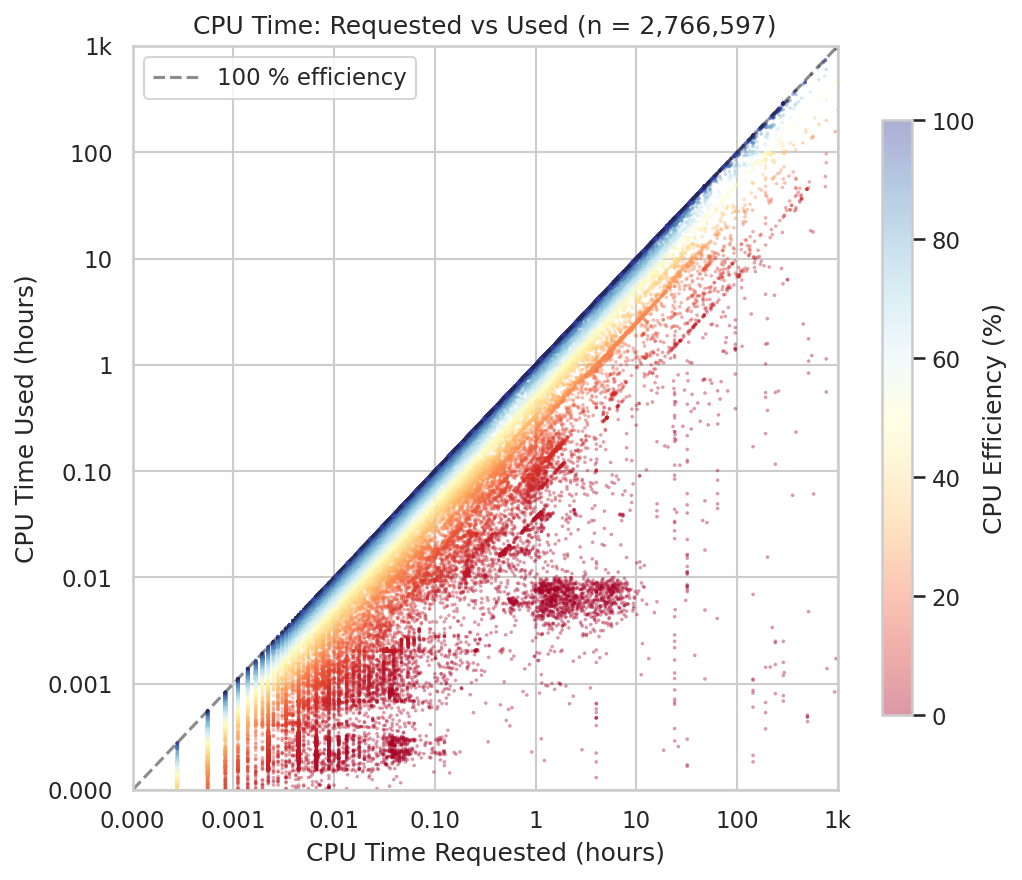

In [13]:
scatter_df = df[['elapsed_sec', 'req_cpus', 'total_cpu_sec',
                  'cpu_eff_req']].dropna()
scatter_df = scatter_df[scatter_df['cpu_eff_req'] <= 100]
scatter_df['cpu_req_hrs'] = (scatter_df['elapsed_sec']
                             * scatter_df['req_cpus'] / 3600)
scatter_df['cpu_used_hrs'] = scatter_df['total_cpu_sec'] / 3600
scatter_df['eff'] = scatter_df['cpu_eff_req']

# Filter out zeros/near-zeros for log scale
scatter_df = scatter_df[(scatter_df['cpu_req_hrs'] > 1e-4)
                        & (scatter_df['cpu_used_hrs'] > 1e-4)]

# Subsample for scatter plot
sample = scatter_df.sample(min(80_000, len(scatter_df)), random_state=42)

def fmt_hrs(x, _):
    if x >= 100_000:
        return f'{x/1_000:.0f}k'
    elif x >= 1_000:
        return f'{x/1_000:.0f}k'
    elif x >= 1:
        return f'{x:.0f}'
    elif x >= 0.01:
        return f'{x:.2f}'
    else:
        return f'{x:.3f}'

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(sample['cpu_req_hrs'], sample['cpu_used_hrs'],
                c=sample['eff'], cmap='RdYlBu', vmin=0, vmax=100,
                s=3, alpha=0.4, edgecolors='none', rasterized=True)
fig.colorbar(sc, ax=ax, label='CPU Efficiency (%)', shrink=0.8)

# Use percentiles to focus on the bulk of data, snap to decades
all_vals = pd.concat([scatter_df['cpu_req_hrs'], scatter_df['cpu_used_hrs']])
lo = 10 ** np.floor(np.log10(all_vals.quantile(0.005)))
hi = 10 ** np.ceil(np.log10(all_vals.quantile(0.995)))
ax.plot([lo, hi], [lo, hi], 'k--', lw=1.5, alpha=0.5, label='100 % efficiency')

ax.set_xlabel('CPU Time Requested (hours)')
ax.set_ylabel('CPU Time Used (hours)')
ax.set_title(f'CPU Time: Requested vs Used (n = {len(scatter_df):,})')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_hrs))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_hrs))
ax.legend()
plt.tight_layout()
savefig('cpu_requested_vs_used.png')
plt.show()

  Saved mem_requested_vs_used.png


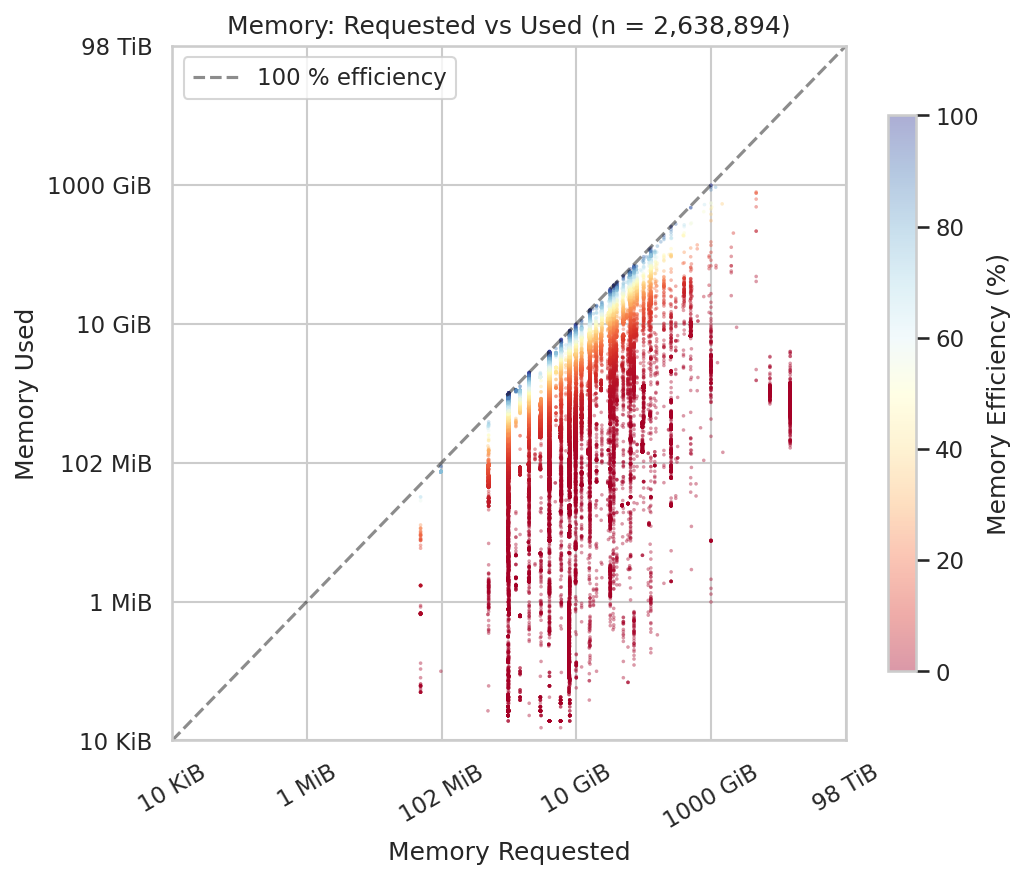

In [14]:
mem_sc = df[['reqmem_bytes', 'maxrss_bytes', 'mem_eff']].dropna()
mem_sc = mem_sc[mem_sc['mem_eff'] <= 100]
mem_sc['req_gib']  = mem_sc['reqmem_bytes'] / (1024**3)
mem_sc['used_gib'] = mem_sc['maxrss_bytes'] / (1024**3)
mem_sc['eff'] = mem_sc['mem_eff']

# Filter out zeros for log scale
mem_sc = mem_sc[(mem_sc['req_gib'] > 0) & (mem_sc['used_gib'] > 0)]

sample = mem_sc.sample(min(80_000, len(mem_sc)), random_state=42)

def fmt_mem(x, _):
    if x >= 1024:
        return f'{x/1024:.0f} TiB'
    elif x >= 1:
        return f'{x:.0f} GiB'
    elif x >= 1/1024:
        return f'{x*1024:.0f} MiB'
    else:
        return f'{x*1024*1024:.0f} KiB'

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(sample['req_gib'], sample['used_gib'],
                c=sample['eff'], cmap='RdYlBu', vmin=0, vmax=100,
                s=3, alpha=0.4, edgecolors='none', rasterized=True)
fig.colorbar(sc, ax=ax, label='Memory Efficiency (%)', shrink=0.8)

# Use percentiles to focus on the bulk of data, snap to decades
all_vals = pd.concat([mem_sc['req_gib'], mem_sc['used_gib']])
lo = 10 ** np.floor(np.log10(all_vals.quantile(0.005)))
hi = 10 ** np.ceil(np.log10(all_vals.quantile(0.995)))
ax.plot([lo, hi], [lo, hi], 'k--', lw=1.5, alpha=0.5, label='100 % efficiency')

ax.set_xlabel('Memory Requested')
ax.set_ylabel('Memory Used')
ax.set_title(f'Memory: Requested vs Used (n = {len(mem_sc):,})')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_mem))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_mem))
ax.tick_params(axis='x', rotation=30)
ax.legend()
plt.tight_layout()
savefig('mem_requested_vs_used.png')
plt.show()

In [16]:
from statsmodels.nonparametric.smoothers_lowess import lowess as sm_lowess

both = df[['cpu_eff_req', 'mem_eff']].dropna()
both = both[(both['cpu_eff_req'] <= 100) & (both['mem_eff'] <= 100)]

# 2D histogram with 10% bins
bins_10 = np.arange(0, 110, 10)
H, xedges, yedges = np.histogram2d(
    both['cpu_eff_req'], both['mem_eff'], bins=[bins_10, bins_10])

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.pcolormesh(xedges, yedges, H.T,
                   cmap='viridis',
                   norm=mcolors.LogNorm(vmin=1, vmax=H.max()))
# Colorbar with readable ticks
cbar = fig.colorbar(im, ax=ax, label='Number of Jobs')
cbar_ticks = [1, 10, 100, 1_000, 10_000, 100_000, 1_000_000]
cbar_ticks = [t for t in cbar_ticks if t <= H.max()]
cbar.set_ticks(cbar_ticks)
cbar.set_ticklabels(['1', '10', '100', '1k', '10k', '100k', '1M'][:len(cbar_ticks)])

# LOWESS trend line (subsample for speed)
sample = both.sample(min(100_000, len(both)), random_state=42)
smoothed = sm_lowess(sample['mem_eff'], sample['cpu_eff_req'], frac=0.3)
ax.plot(smoothed[:, 0], smoothed[:, 1], color='red', linewidth=2.5,
        label='LOWESS trend')

ax.set_xlabel('CPU Efficiency (%)')
ax.set_ylabel('Memory Efficiency (%)')
ax.set_title(f'CPU and Memory Efficiency Heatmap\n'
             f'(n = {len(both):,})')
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_xticks(np.arange(0, 110, 10))
ax.set_yticks(np.arange(0, 110, 10))
ax.set_xticklabels([f'{x}%' for x in range(0, 110, 10)])
ax.set_yticklabels([f'{y}%' for y in range(0, 110, 10)])

# Spearman correlation
rho, pval = sp_stats.spearmanr(both['cpu_eff_req'], both['mem_eff'])
ax.text(0.02, 0.98, f'Spearman ρ = {rho:.3f}',
        transform=ax.transAxes, fontsize=12, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.legend(loc='lower right')
plt.tight_layout()
savefig('cpu_vs_mem_efficiency.png')
plt.show()

ModuleNotFoundError: No module named 'statsmodels'

---
# 2. Faculty Efficiency Stats

In [ ]:
df_out = df_agg.sort_values('job_count', ascending=True).copy()

fig, ax = plt.subplots(figsize=(9, max(7, len(df_out) * 0.7)))

y = range(len(df_out))
ax.barh(y, df_out['job_count_success'].values, color=C_OK,
        label='Completed', alpha=0.8)
ax.barh(y, df_out['job_count_failed'].values,
        left=df_out['job_count_success'].values,
        color=C_FAIL, label='Failed', alpha=0.8)
ax.barh(y, df_out['cancelled'].values,
        left=(df_out['job_count_success'] + df_out['job_count_failed']).values,
        color=C_CAN, label='Cancelled', alpha=0.8)

ax.set_yticks(list(y))
ax.set_yticklabels(df_out['faculty_short'].values, fontsize=9)
ax.set_xlabel('Number of Jobs')
ax.xaxis.set_major_formatter(COUNT_FMT)
ax.set_title('Job Outcomes by Faculty')
ax.legend(loc='lower right', borderaxespad=2)

# Annotate totals at tip
max_count = df_out['job_count'].max()
for i, (_, row) in enumerate(df_out.iterrows()):
    ax.text(row['job_count'] + max_count * 0.005, i,
            f'{row["job_count"]:,}', va='center', fontsize=9)

# Enough room for annotations
ax.set_xlim(0, max_count * 1.15)

plt.tight_layout()
savefig('faculty_job_outcomes.png')
plt.show()

display(Markdown('''
*Numbers at the tip of each bar show the total number of jobs submitted.*

**State definitions:**
- **Completed**: jobs that finished successfully (Slurm state COMPLETED).
- **Failed**: jobs that terminated abnormally — includes FAILED, TIMEOUT,
  NODE_FAIL, PREEMPTED, and OUT_OF_MEMORY.
- **Cancelled**: jobs cancelled by the user or an administrator before
  completion (excluded from failure counts as these are intentional).
'''))

  Saved faculty_efficiency_barplots.png


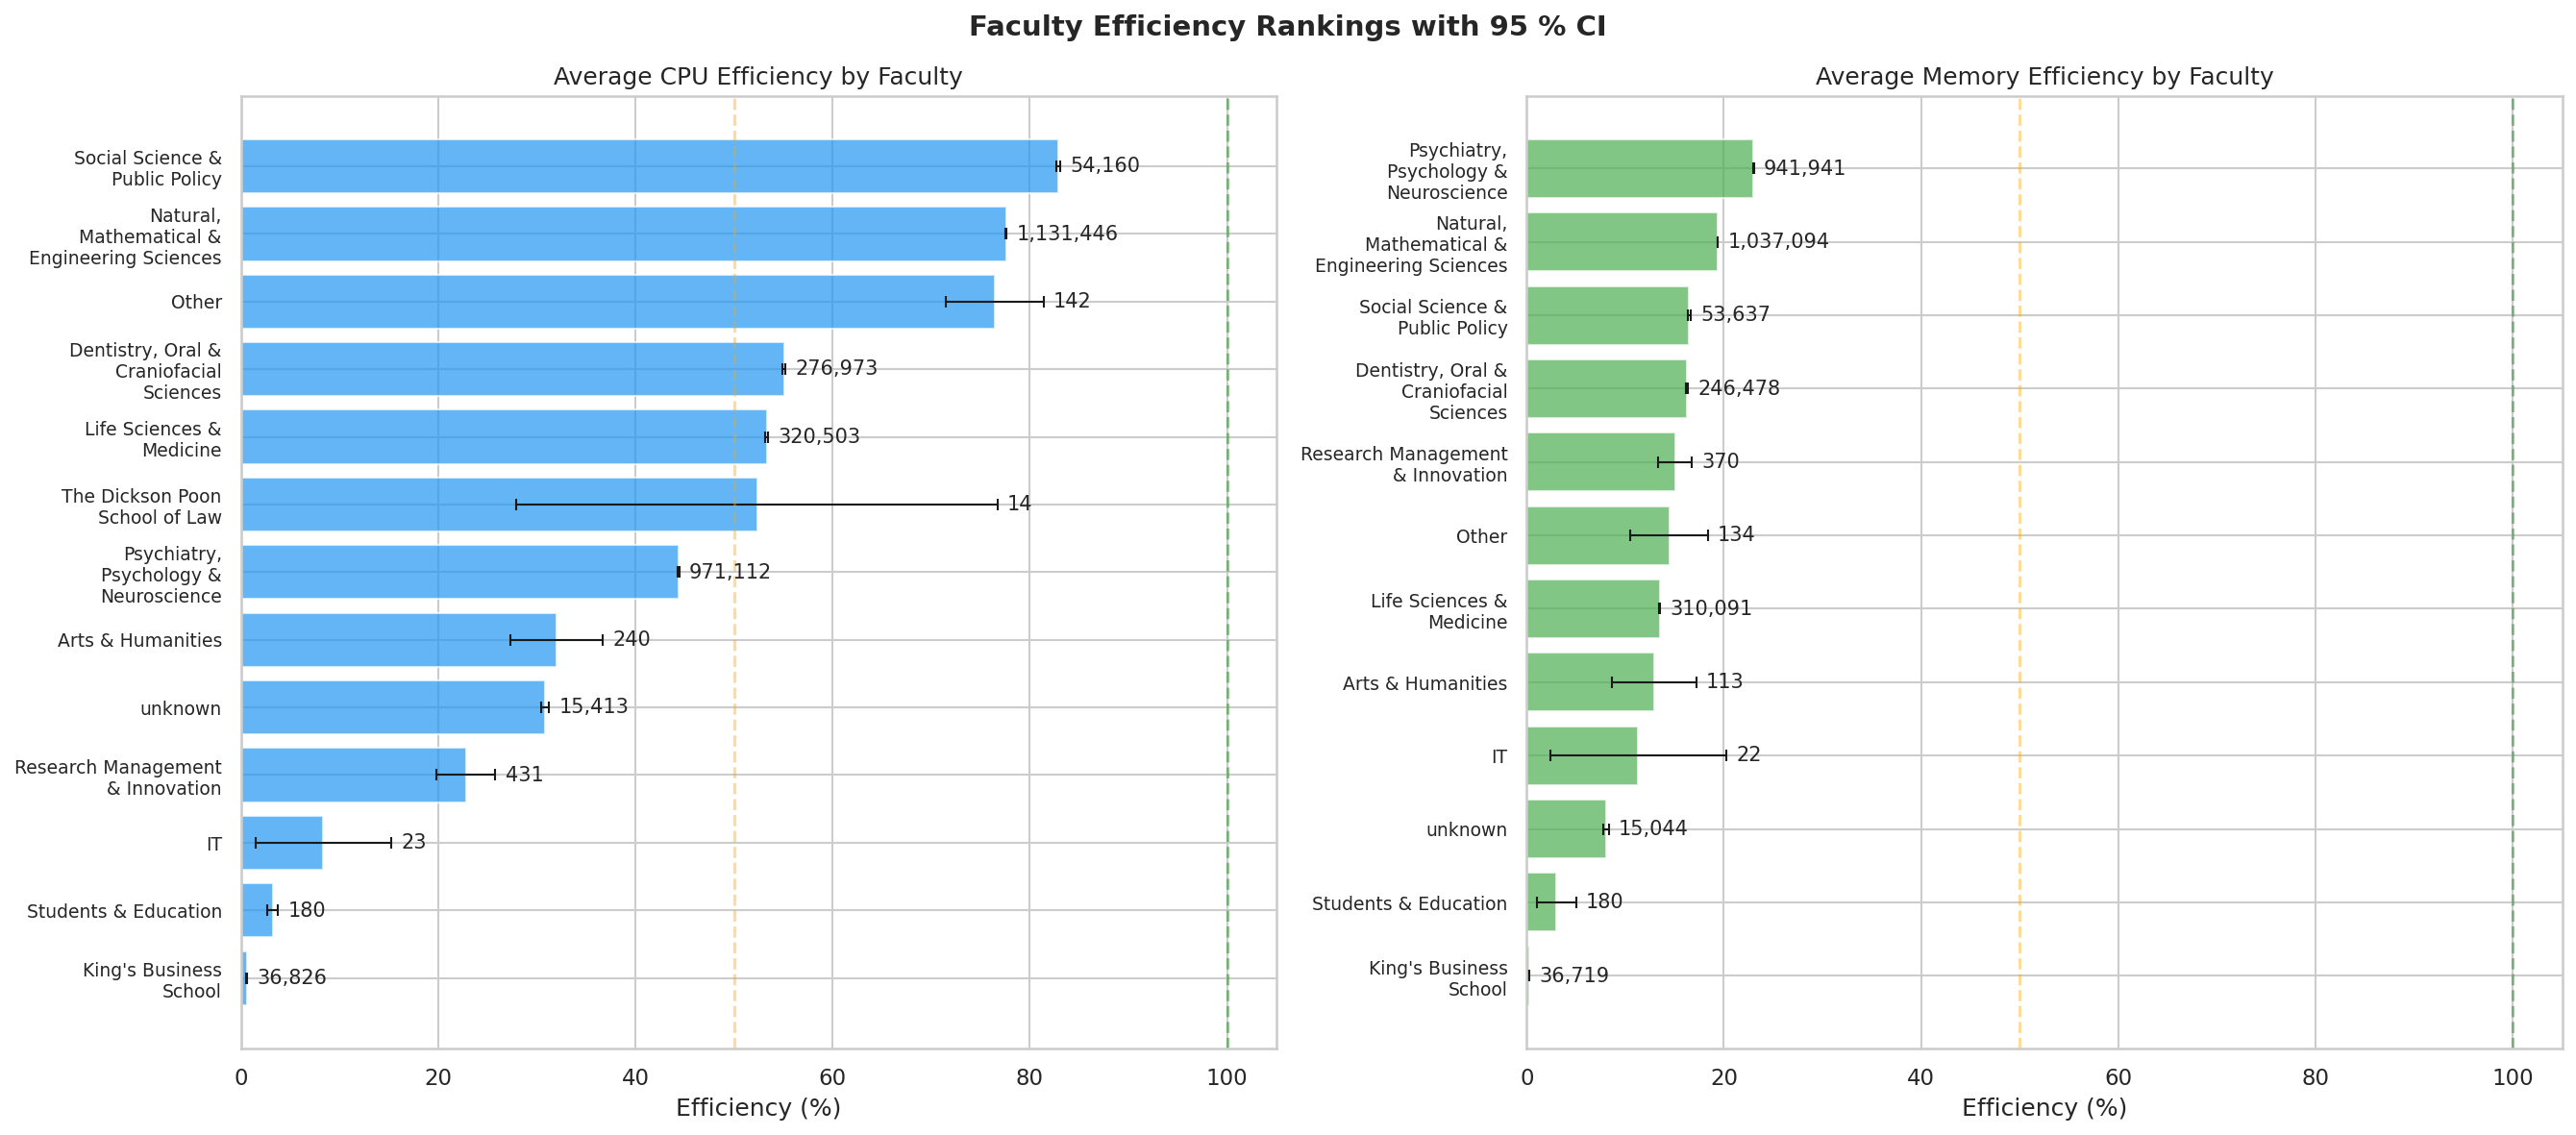


*Numbers at the tip of each bar indicate the number of jobs included
(with valid efficiency ≤ 100 %). Error bars show 95 % confidence intervals
around the mean.*


In [ ]:
def faculty_ci_stats(col):
    """Compute per-faculty mean and 95% CI from job-level data (eff <= 100%)."""
    rows = []
    for fac in df['faculty'].unique():
        vals = df.loc[df['faculty'] == fac, col].dropna()
        vals = vals[vals <= 100]
        if len(vals) < 5:
            continue
        mean = vals.mean()
        se   = vals.std() / np.sqrt(len(vals))
        ci   = 1.96 * se
        rows.append({
            'faculty': fac,
            'faculty_short': SHORT.get(fac, fac),
            'mean': mean,
            'ci': ci,
            'n': len(vals),
        })
    return pd.DataFrame(rows).sort_values('mean', ascending=True)

cpu_fstats = faculty_ci_stats('cpu_eff_req')
mem_fstats = faculty_ci_stats('mem_eff')

fig, axes = plt.subplots(1, 2, figsize=(18, max(8, len(cpu_fstats) * 0.6)))

for ax, fstats, color, title in [
    (axes[0], cpu_fstats, C_CPU, 'Average CPU Efficiency by Faculty'),
    (axes[1], mem_fstats, C_MEM, 'Average Memory Efficiency by Faculty'),
]:
    y = range(len(fstats))
    ax.barh(y, fstats['mean'], xerr=fstats['ci'],
            color=color, alpha=0.7, edgecolor='white',
            capsize=3, error_kw={'lw': 1})
    ax.set_yticks(list(y))
    ax.set_yticklabels(fstats['faculty_short'], fontsize=9)
    ax.set_xlabel('Efficiency (%)')
    ax.set_title(title)
    ax.set_xlim(0, 105)
    ax.axvline(50, color='orange', ls='--', alpha=0.4)
    ax.axvline(100, color='green', ls='--', alpha=0.4)

    # Annotate job counts at tip of bar
    for i, (_, row) in enumerate(fstats.iterrows()):
        ax.text(row['mean'] + row['ci'] + 1, i,
                f'{row["n"]:,}', va='center', fontsize=10)

plt.suptitle('Faculty Efficiency Rankings with 95 % CI',
             fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('faculty_efficiency_barplots.png')
plt.show()

display(Markdown('''
*Numbers at the tip of each bar indicate the number of jobs included
(with valid efficiency \u2264 100 %). Error bars show 95 % confidence intervals
around the mean.*
'''))

  Saved faculty_efficiency_violins.png


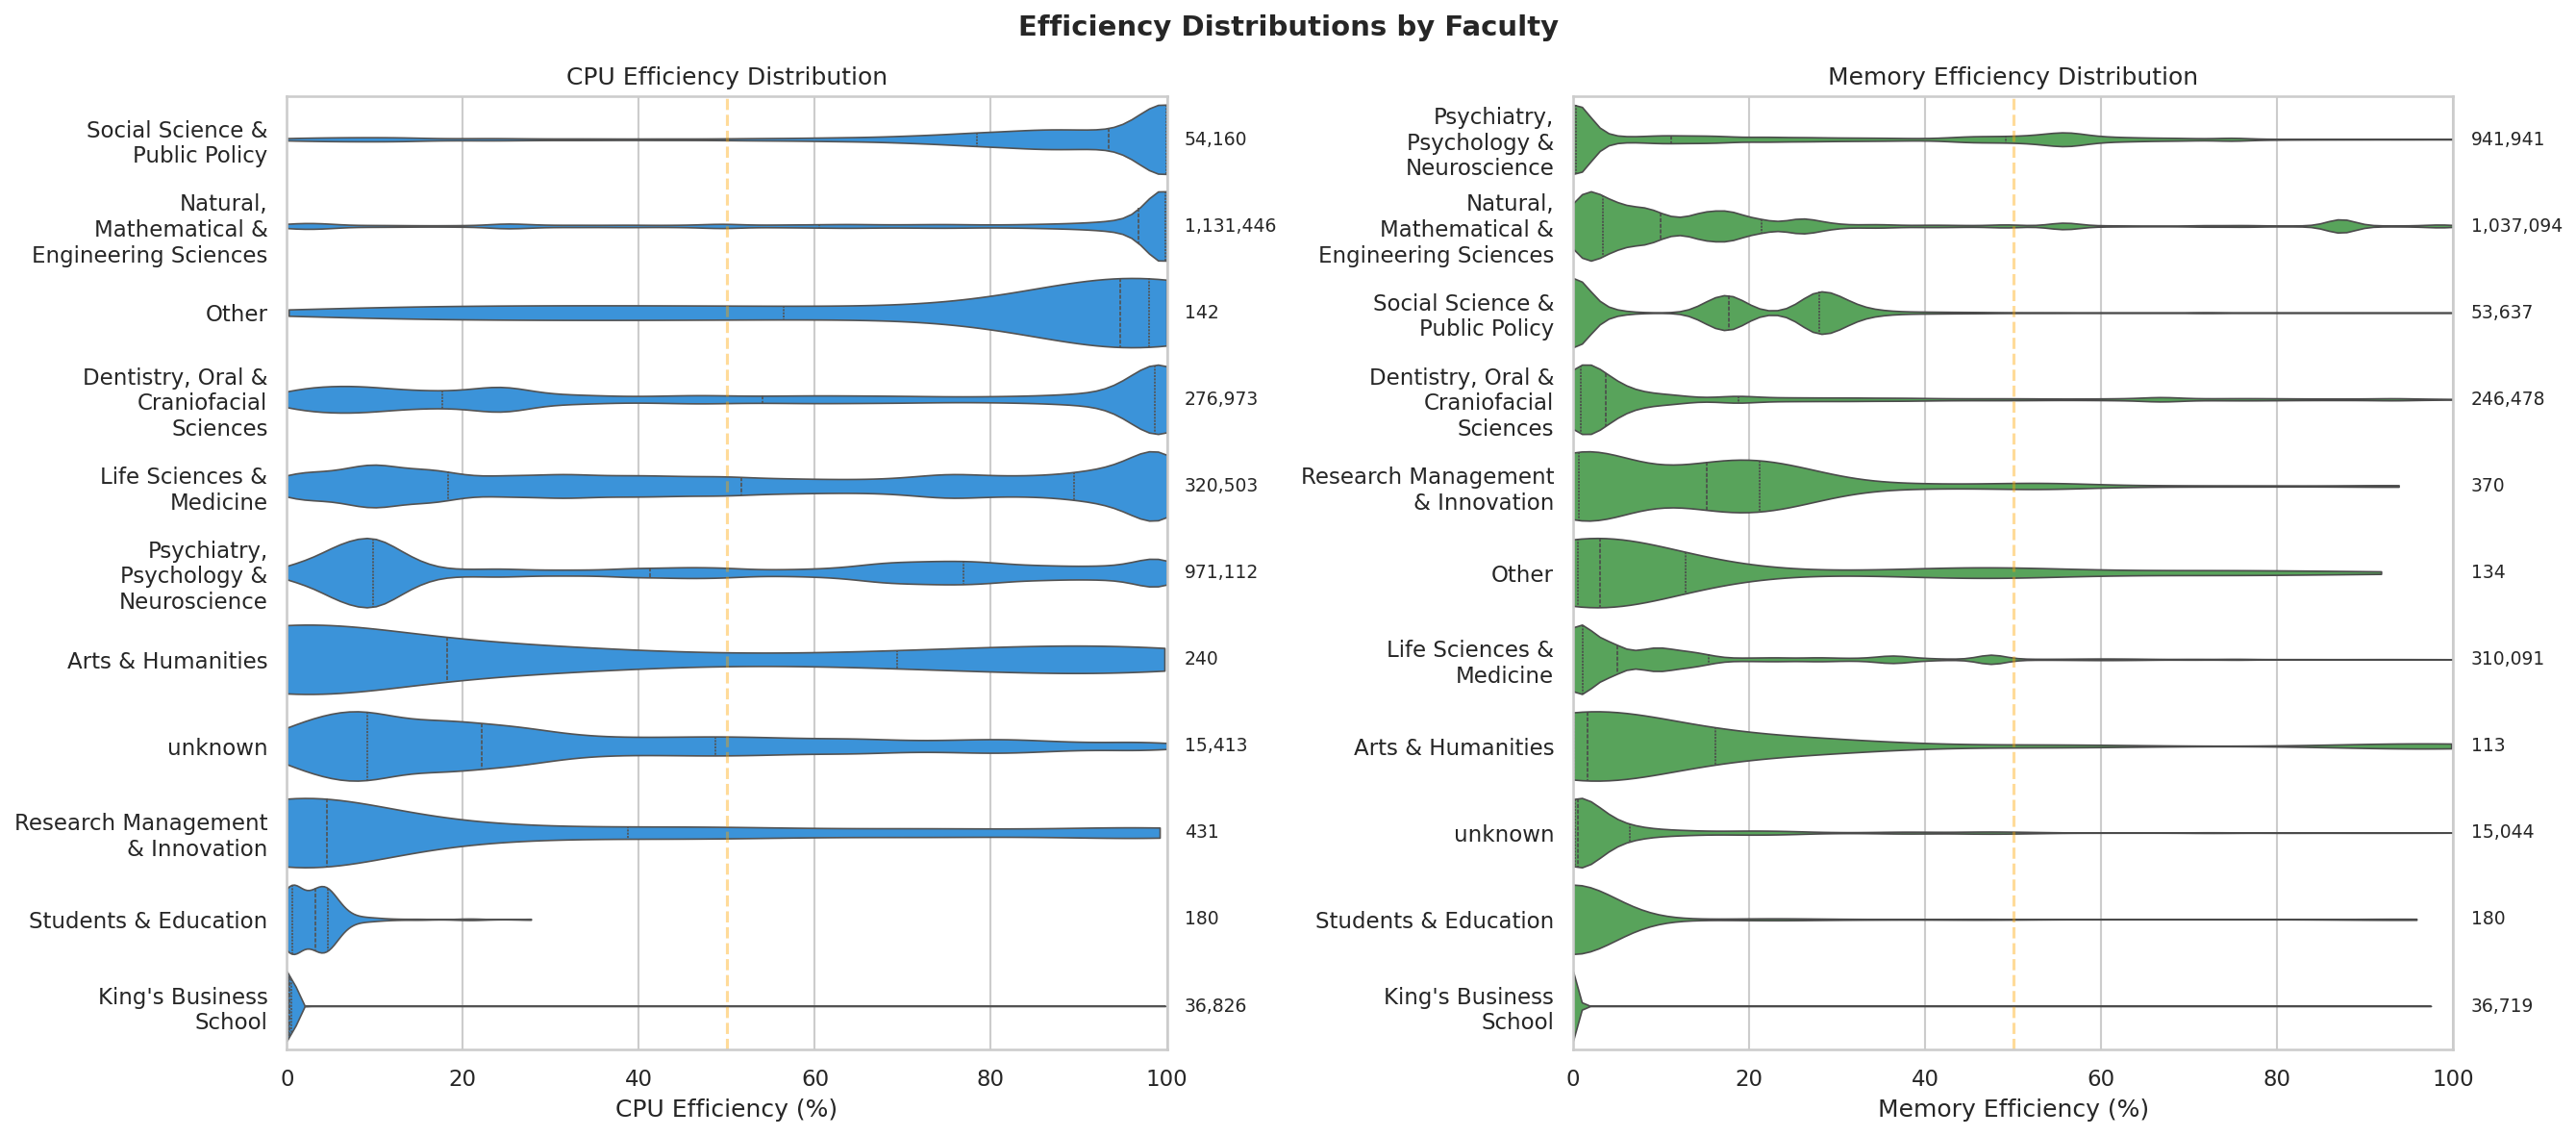


*Numbers next to each violin indicate the number of jobs included
(with valid efficiency ≤ 100 %). Faculties with fewer than 50 jobs are
excluded. Internal lines show quartiles (25th, 50th, 75th percentile).*


In [ ]:
# Only faculties with >= 50 jobs for meaningful violins
fac_counts = df['faculty'].value_counts()
big_facs = fac_counts[fac_counts >= 50].index.tolist()

# Order by mean CPU efficiency (desc) for CPU, by mean mem eff for mem
fac_cpu_means = (df[df['faculty'].isin(big_facs) & (df['cpu_eff_req'] <= 100)
                    & df['cpu_eff_req'].notna()]
                 .groupby('faculty')['cpu_eff_req'].mean()
                 .sort_values(ascending=False))
fac_order_cpu = [SHORT.get(f, f) for f in fac_cpu_means.index]

fac_mem_means = (df[df['faculty'].isin(big_facs) & (df['mem_eff'] <= 100)
                    & df['mem_eff'].notna()]
                 .groupby('faculty')['mem_eff'].mean()
                 .sort_values(ascending=False))
fac_order_mem = [SHORT.get(f, f) for f in fac_mem_means.index]

fig, axes = plt.subplots(1, 2, figsize=(18, max(8, len(big_facs) * 0.65)))

# CPU violin
cpu_vdata = df[df['faculty'].isin(big_facs)
               & df['cpu_eff_req'].notna()
               & (df['cpu_eff_req'] <= 100)].copy()
sns.violinplot(data=cpu_vdata, y='faculty_short', x='cpu_eff_req',
               ax=axes[0], cut=0, order=fac_order_cpu,
               density_norm='width', inner='quartile', color=C_CPU,
               linewidth=0.8)
axes[0].set_xlabel('CPU Efficiency (%)')
axes[0].set_ylabel('')
axes[0].set_title('CPU Efficiency Distribution')
axes[0].axvline(50, color='orange', ls='--', alpha=0.4)
axes[0].set_xlim(0, 100)

# Annotate with job counts
for i, fac_short in enumerate(fac_order_cpu):
    fac_full = [k for k, v in SHORT.items() if v == fac_short]
    if fac_full:
        n = len(cpu_vdata[cpu_vdata['faculty'] == fac_full[0]])
        axes[0].text(102, i, f'{n:,}', va='center', fontsize=9)

# Memory violin
mem_vdata = df[df['faculty'].isin(big_facs)
               & df['mem_eff'].notna()
               & (df['mem_eff'] <= 100)].copy()
sns.violinplot(data=mem_vdata, y='faculty_short', x='mem_eff',
               ax=axes[1], cut=0, order=fac_order_mem,
               density_norm='width', inner='quartile', color=C_MEM,
               linewidth=0.8)
axes[1].set_xlabel('Memory Efficiency (%)')
axes[1].set_ylabel('')
axes[1].set_title('Memory Efficiency Distribution')
axes[1].axvline(50, color='orange', ls='--', alpha=0.4)
axes[1].set_xlim(0, 100)

for i, fac_short in enumerate(fac_order_mem):
    fac_full = [k for k, v in SHORT.items() if v == fac_short]
    if fac_full:
        n = len(mem_vdata[mem_vdata['faculty'] == fac_full[0]])
        axes[1].text(102, i, f'{n:,}', va='center', fontsize=9)

plt.suptitle('Efficiency Distributions by Faculty',
             fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('faculty_efficiency_violins.png')
plt.show()

display(Markdown('''
*Numbers next to each violin indicate the number of jobs included
(with valid efficiency \u2264 100 %). Faculties with fewer than 50 jobs are
excluded. Internal lines show quartiles (25th, 50th, 75th percentile).*
'''))